# Identify CSTR-separator (4x4) SS using PARSIM-K (closed-loop HPO trial 117)


In [80]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
import numpy as np
import sys
import joblib
from sklearn.preprocessing import StandardScaler

from sippy_unipi import system_identification
from sippy_unipi import functionsetSIM as fsetSIM

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

import models
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the identification dataset


In [81]:
# Plant used to generate ../data/cstr_separator_ident.npz (square 4x4 variant)
CSTR = models.CSTRSeparator4x4()


In [82]:
# Load pre-generated CSTR-separator identification data (square 4x4 variant)
# Y: [T1, T2, T3, xB3], U: [Q1, Q2, Q3, F10] (F20, Fr fixed; yield-paired steps, 180 s holds)
data = np.load("../data/cstr_separator_ident.npz", allow_pickle=True)
sim = {"Y": np.array(data["Y"], dtype=float), "U": np.array(data["U"], dtype=float)}
print("Loaded", data.files)
print("Y", sim["Y"].shape, list(data["y_names"]))
print("U", sim["U"].shape, list(data["u_names"]))
print("Ts =", float(data["Ts"]), "step_time =", int(data["step_time"]), "no_steps =", int(data["no_steps"]))


Loaded ['Y', 'Y_clean', 'U', 'X', 'U_plant', 'Ts', 'step_time', 'no_steps', 'y_names', 'u_names', 'x0', 'u_nom', 'mv_constraints', 'noise_frac', 'noise_sigma', 'noise_seed', 'n_train_noise']
Y (18000, 4) [np.str_('T1'), np.str_('T2'), np.str_('T3'), np.str_('xB3')]
U (18000, 4) [np.str_('Q1'), np.str_('Q2'), np.str_('Q3'), np.str_('F10')]
Ts = 1.0 step_time = 180 no_steps = 100


In [83]:
# Measurement noise is already in Y (1% of train-range, stored in the npz).
if "noise_sigma" in data.files:
    print("Stored measurement noise (already in Y):")
    for name, s in zip(data["y_names"], np.array(data["noise_sigma"], dtype=float)):
        print(f"  {name}: sigma={s:.4g}")
    print("noise_frac =", float(data["noise_frac"]), "seed =", int(data["noise_seed"]))


Stored measurement noise (already in Y):
  T1: sigma=0.4866
  T2: sigma=0.5267
  T3: sigma=0.6101
  xB3: sigma=0.003435
noise_frac = 0.01 seed = 42


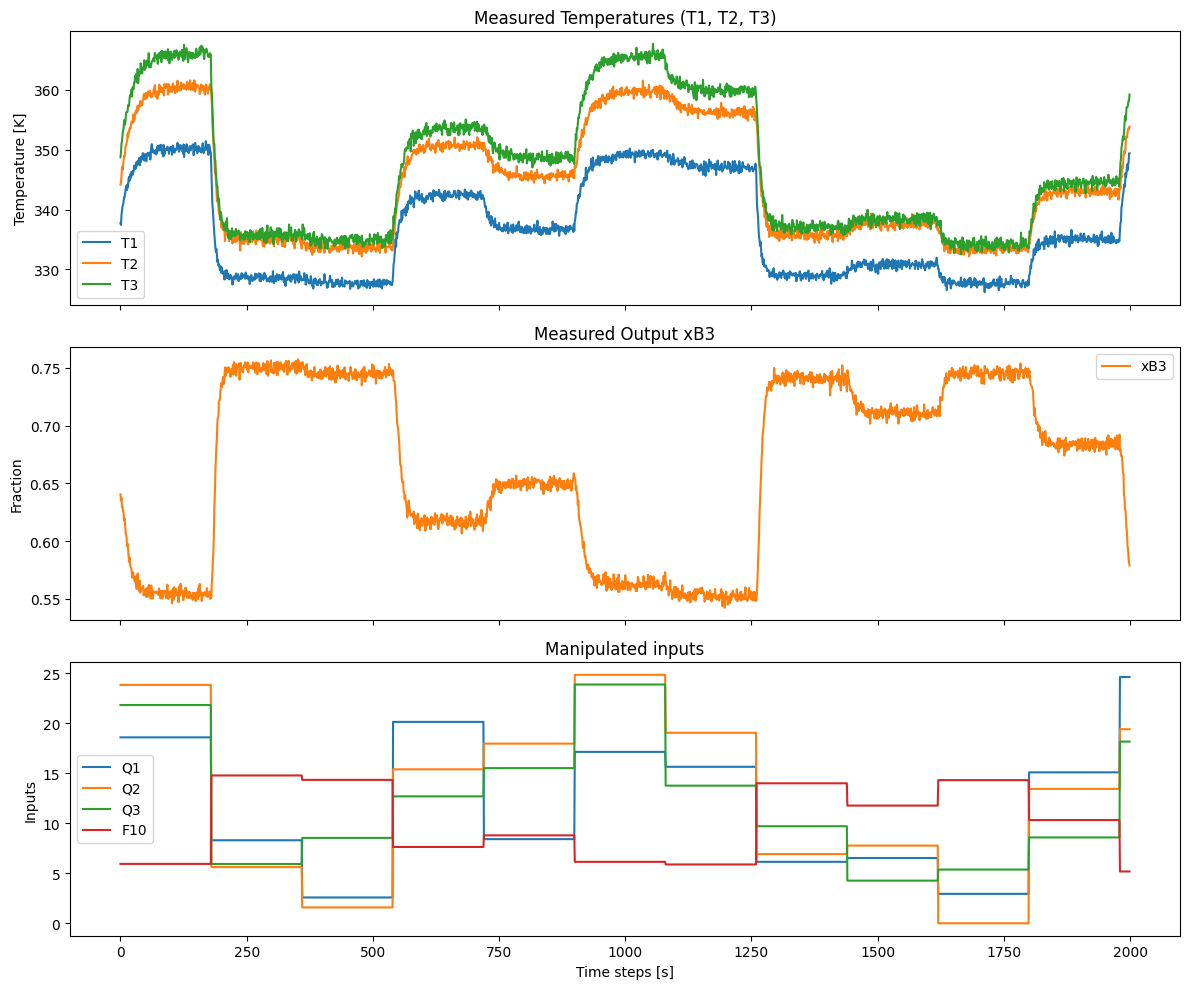

In [84]:
part = 2000
y_names = list(data["y_names"])
u_names = list(data["u_names"])  # ["Q1", "Q2", "Q3", "F10"]; F20, Fr fixed

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot T1, T2, T3 together
for i, name in enumerate(y_names[:-1]):  # T1, T2, T3
    axes[0].plot(sim["Y"][:part, i], label=name)
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Measured Temperatures (T1, T2, T3)")
axes[0].legend()

# Plot xB3 separately
axes[1].plot(sim["Y"][:part, 3], label="xB3", color="tab:orange")
axes[1].set_ylabel("Fraction")
axes[1].set_title("Measured Output xB3")
axes[1].legend()

# Plot inputs
for i, name in enumerate(u_names):
    axes[2].plot(sim["U"][:part, i], label=name)
axes[2].set_xlabel("Time steps [s]")
axes[2].set_ylabel("Inputs")
axes[2].set_title("Manipulated inputs")
axes[2].legend()

plt.tight_layout()
plt.show()


In [85]:
# Fit scalers on the training split (same convention as Koopman notebooks)
n_train, n_dev = 12960, 2880
train_raw = {key: value[:n_train] for key, value in sim.items()}
dev_raw = {key: value[n_train:n_train + n_dev] for key, value in sim.items()}
test_raw = {key: value[n_train + n_dev:] for key, value in sim.items()}

scaler = StandardScaler()
scaler.fit(train_raw["Y"])
joblib.dump(scaler, "../data/scaler_cstr_separator.pkl")

scalerU = StandardScaler()
scalerU.fit(train_raw["U"])
joblib.dump(scalerU, "../data/scalerU_cstr_separator.pkl")


['../data/scalerU_cstr_separator.pkl']

In [86]:
train_sim = {
    "Y": scaler.transform(train_raw["Y"]),
    "U": scalerU.transform(train_raw["U"]),
}
dev_sim = {
    "Y": scaler.transform(dev_raw["Y"]),
    "U": scalerU.transform(dev_raw["U"]),
}
test_sim = {
    "Y": scaler.transform(test_raw["Y"]),
    "U": scalerU.transform(test_raw["U"]),
}
print("train", train_sim["Y"].shape, "dev", dev_sim["Y"].shape, "test", test_sim["Y"].shape)


train (12960, 4) dev (2880, 4) test (2160, 4)


## Identification using PARSIM-K


In [87]:
# SIPPY wants (n_signals, N). It auto-transposes, but be explicit.
y_tot = train_sim["Y"].T.copy()
U = train_sim["U"].T.copy()
print("y_tot", y_tot.shape, "U", U.shape)


y_tot (4, 12960) U (4, 12960)


In [88]:
# # Closed-loop HPO trial 117 (PARSIM-K n=15, SS_f=20, SS_p=30, MeanVal, B_reval).
# # Drop real-Schur blocks with |λ| > RHO_MAX (tunable spectral-radius cutoff).
# from numpy.linalg import eigvals, inv

# import helper
# from hpo_sippy_cl import SippyParams, identify_sippy, patch_sippy_vn_mat

# patch_sippy_vn_mat()
# params = SippyParams(
#     method="N4SID",
#     n=15,
#     f_extra=5,
#     centering="MeanVal",
#     p_over_f=1.5,
#     SS_PK_B_reval=True,
# )
# sys_id = identify_sippy(y_tot.copy(), U.copy(), "N4SID", 15)

# RHO_MAX = 0.99  # keep |λ| ≤ this; 0.984 drops the sluggish pair and real pole


# def _print_poles(A, title):
#     ev = eigvals(A)
#     mag = np.abs(ev)
#     print(f"{title}  n={A.shape[0]}  rho={mag.max():.5f}")
#     for lam in ev[np.argsort(-mag)]:
#         m = abs(lam)
#         tau = np.inf if m >= 1.0 else -1.0 / np.log(m)
#         print(f"  |λ|={m:.5f}  τ={tau:6.2f} samples  λ={lam.real:+.4f}{lam.imag:+.4f}j")


# def drop_slow_modes(A, B, C, rho_max=RHO_MAX):
#     """Keep real-Schur blocks with |λ| ≤ rho_max; discard slower modes."""
#     T, Ab = helper.ident.real_block_diagonalize(np.asarray(A, dtype=float))
#     Bt = inv(T) @ np.asarray(B, dtype=float)
#     Ct = np.asarray(C, dtype=float) @ T
#     n = Ab.shape[0]
#     keep = np.zeros(n, dtype=bool)
#     i = 0
#     while i < n:
#         pair = (
#             i + 1 < n
#             and abs(Ab[i, i + 1]) > 1e-8
#             and abs(Ab[i + 1, i]) > 1e-8
#         )
#         if pair:
#             rho = float(np.max(np.abs(eigvals(Ab[i : i + 2, i : i + 2]))))
#             keep[i : i + 2] = rho <= rho_max
#             i += 2
#         else:
#             keep[i] = abs(Ab[i, i]) <= rho_max
#             i += 1
#     idx = np.where(keep)[0]
#     if idx.size == 0:
#         raise RuntimeError("drop_slow_modes removed every mode")
#     return Ab[np.ix_(idx, idx)], Bt[idx, :], Ct[:, idx]


# _print_poles(sys_id.A, "identified")
# sys_id.A, sys_id.B, sys_id.C = drop_slow_modes(sys_id.A, sys_id.B, sys_id.C, rho_max=RHO_MAX)
# sys_id.D = np.zeros((sys_id.C.shape[0], sys_id.B.shape[1]))
# _print_poles(sys_id.A, f"after dropping |λ| > {RHO_MAX}")
# print(
#     f"trial 117 PARSIM-K  n={sys_id.A.shape[0]}  SS_f={params.SS_f}  SS_p={params.SS_p}  "
#     f"centering={params.centering}  B_reval={params.SS_PK_B_reval}  "
#     f"rho={np.max(np.abs(eigvals(sys_id.A))):.5f}"
# )


In [89]:
import warnings
from hpo_sippy_cl import SippyParams, identify_sippy, patch_sippy_vn_mat

patch_sippy_vn_mat()

U_test = test_sim["U"].T
Y_test = test_sim["Y"].T
order_results = []
sys_id = None
best_mae = np.inf

# Horizon must exceed the largest order (SIPPY default SS_f=20 would cap n at 20).
SS_f = 20
print(f"{'order':>5}  {'test MAE':>12}  {'test MSE':>12}  {'rho(A)':>10}")
for n in range(4, 20):
    ident = identify_sippy(
        y_tot.copy(),
        U.copy(),
        SippyParams(
            method="N4SID",
            n=int(n),
            f_extra=int(SS_f - n),
            centering="None",
            SS_A_stability=True,
        ),
    )
    _, y_hat = fsetSIM.SS_lsim_process_form(
        ident.A, ident.B, ident.C, ident.D,
        U_test,
        np.linalg.pinv(ident.C) @ Y_test[:, :1],
    )
    err = Y_test - y_hat
    mae = float(np.mean(np.abs(err)))
    mse = float(np.mean(err ** 2))
    rho = float(np.max(np.abs(np.linalg.eigvals(ident.A))))
    order_results.append({"order": n, "mae": mae, "mse": mse, "rho": rho, "sys": ident})
    print(f"{n:5d}  {mae:12.6g}  {mse:12.6g}  {rho:10.5f}")
    if mae < best_mae:
        best_mae = mae
        sys_id = ident

print(f"best test MAE: order {sys_id.A.shape[0]}  MAE={best_mae:.6g}")


order      test MAE      test MSE      rho(A)
    4       0.34812      0.212211     0.98634
    5      0.293085      0.127472     0.98607
    6      0.284172      0.121729     0.98649
    7      0.290916      0.124446     0.98657
    8      0.288165      0.122921     0.98733
    9      0.288735      0.123263     0.98729
   10      0.288467      0.123303     0.98723
   11      0.288343      0.123196     0.98708
   12      0.287725      0.122804     0.98716
   13      0.287845      0.122866     0.98709
   14      0.288525      0.123205     0.98705
   15      0.288208      0.123019     0.98698
   16      0.288565      0.123224     0.98694
   17      0.288193      0.123015     0.98697
   18      0.288221      0.123039     0.98704
   19      0.288436      0.123191     0.98697
best test MAE: order 6  MAE=0.284172


In [90]:
# Matrices already identified in the previous cell (trial 117 settings).
ident = sys_id

In [91]:
sys_id.A


array([[ 9.43647834e-01, -6.36161421e-02, -1.49222885e-02,
         8.73458955e-03,  5.32056604e-03,  1.29696993e-02],
       [-2.54941156e-03,  9.88595863e-01,  1.59275447e-02,
         5.84020109e-02,  7.97603204e-03,  3.55965824e-02],
       [ 4.52756126e-03, -3.03154760e-04,  9.71617530e-01,
        -2.34896516e-02,  5.42214005e-02,  2.56340741e-02],
       [-9.35518269e-02, -1.09310757e-01,  1.73304370e-02,
         7.61730979e-01, -2.38444795e-03, -6.77025826e-04],
       [ 5.42082681e-02,  5.96400684e-02, -1.77740138e-03,
         1.22656783e-01,  9.09414989e-01, -2.44135610e-02],
       [ 7.12834388e-03,  7.55022300e-03,  3.98437668e-03,
        -2.67203159e-03, -3.69710017e-02,  9.40171943e-01]])

In [92]:
append = "_cstr_separator_parsimK"
np.save("../data/A" + append + ".npy", sys_id.A)
np.save("../data/B" + append + ".npy", sys_id.B)
np.save("../data/C" + append + ".npy", sys_id.C)
np.save("../data/D" + append + ".npy", sys_id.D)
# Control notebooks / weight_sweep load the sippy_hpo stem.
for stem in ("_cstr_separator_sippy_hpo",):
    np.save("../data/A" + stem + ".npy", sys_id.A)
    np.save("../data/B" + stem + ".npy", sys_id.B)
    np.save("../data/C" + stem + ".npy", sys_id.C)
    np.save("../data/D" + stem + ".npy", sys_id.D)


In [93]:
xid, yid = fsetSIM.SS_lsim_process_form(
    sys_id.A, sys_id.B, sys_id.C, sys_id.D,
    test_sim["U"].T,
    np.linalg.pinv(sys_id.C) @ test_sim["Y"][0].reshape(-1, 1),
)


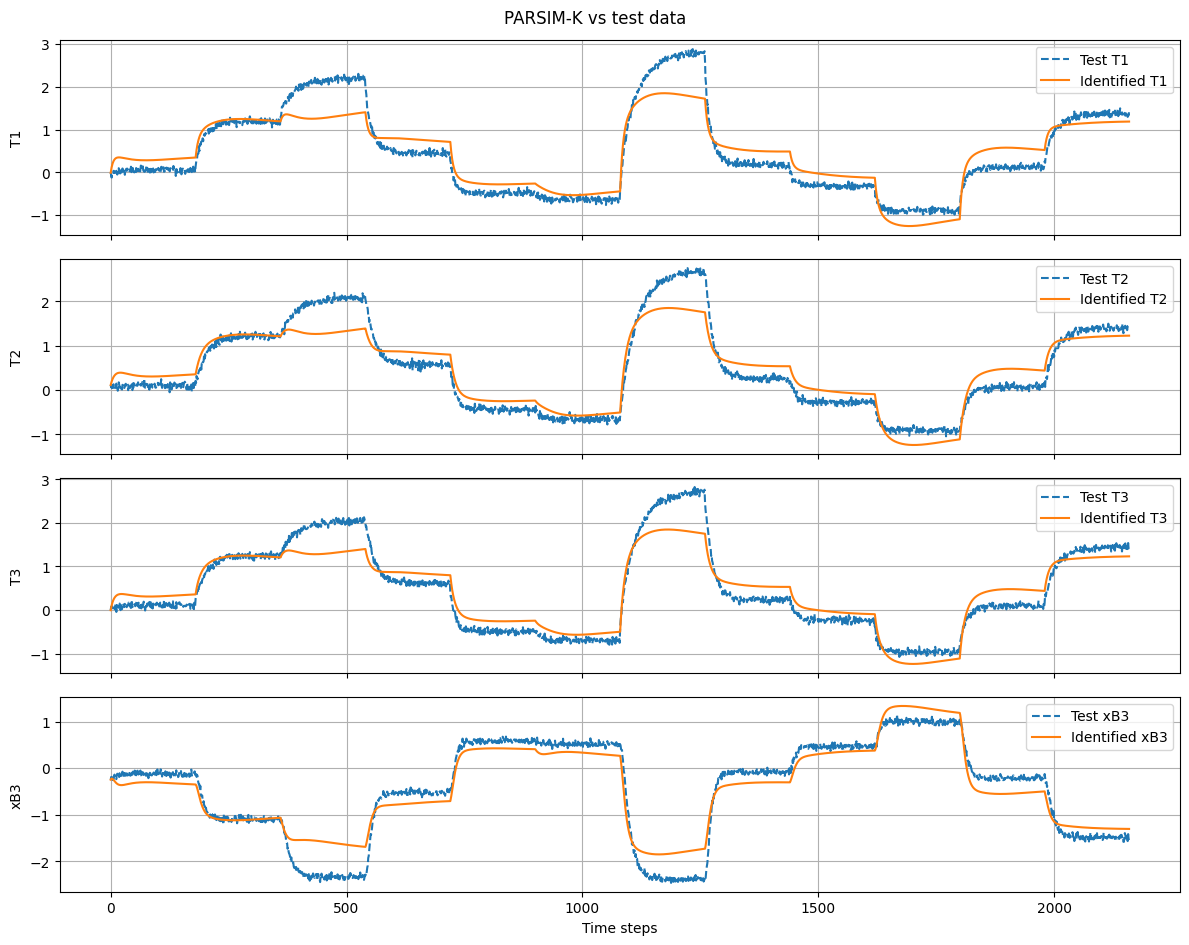

Test MAE per output: [0.3193633  0.28269754 0.275423   0.25920258]
Sum of MAE: 1.1366864256296836


In [94]:
y_names = ["T1", "T2", "T3", "xB3"]
n_y = test_sim["Y"].shape[1]
fig, axes = plt.subplots(n_y, 1, figsize=(12, 2.4 * n_y), sharex=True)
if n_y == 1:
    axes = [axes]
for i, name in enumerate(y_names[:n_y]):
    axes[i].plot(test_sim["Y"][:, i], label=f"Test {name}", linestyle="--")
    axes[i].plot(yid[i, :], label=f"Identified {name}")
    axes[i].set_ylabel(name)
    axes[i].legend()
    axes[i].grid()
axes[-1].set_xlabel("Time steps")
fig.suptitle("PARSIM-K vs test data")
plt.tight_layout()
plt.show()

test_mae = np.mean(np.abs(test_sim["Y"].T - yid), axis=1)
print("Test MAE per output:", test_mae)
print("Sum of MAE:", np.sum(test_mae))


In [95]:
xid, yid = fsetSIM.SS_lsim_process_form(
    sys_id.A, sys_id.B, sys_id.C, sys_id.D,
    train_sim["U"].T,
    np.linalg.pinv(sys_id.C) @ train_sim["Y"][0].reshape(-1, 1),
)


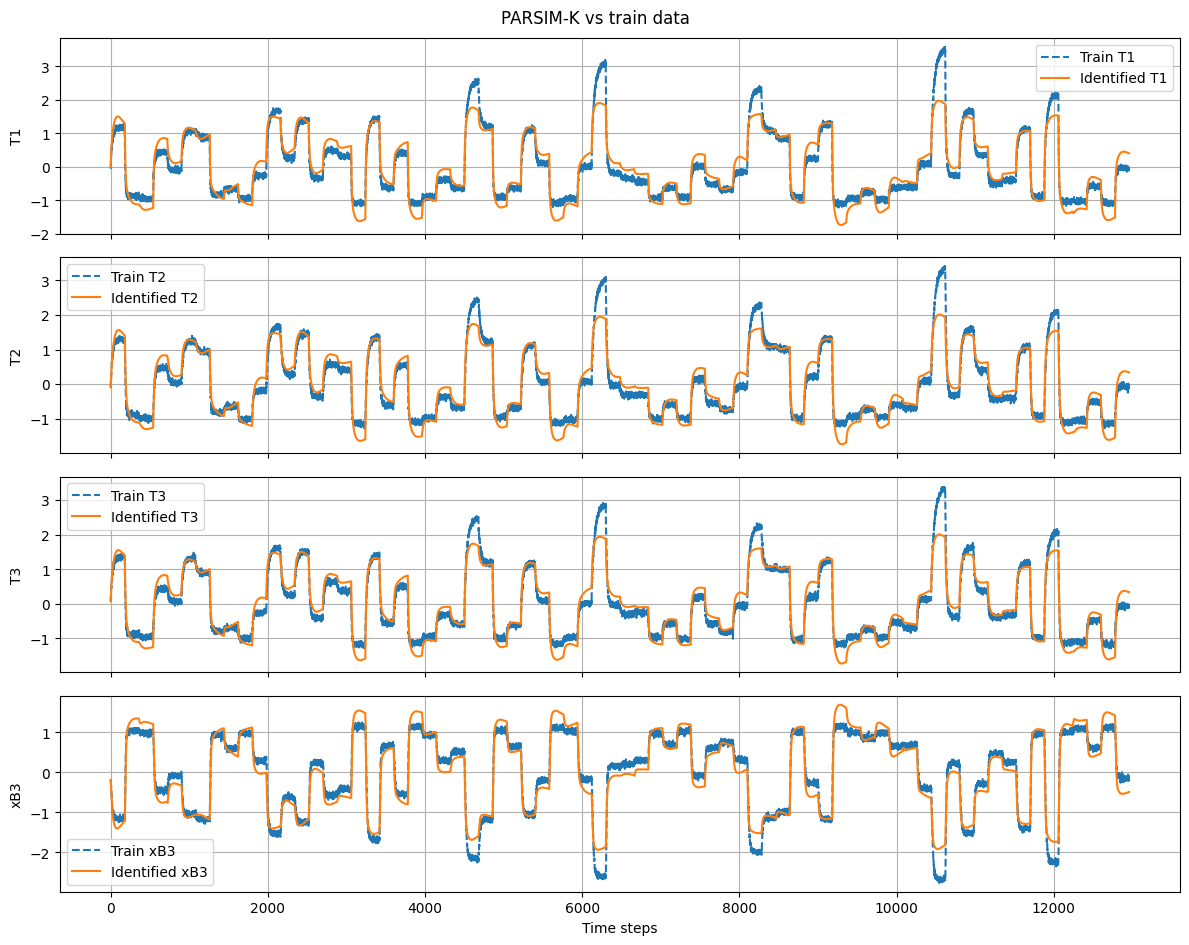

In [96]:
y_names = ["T1", "T2", "T3", "xB3"]
n_y = train_sim["Y"].shape[1]
fig, axes = plt.subplots(n_y, 1, figsize=(12, 2.4 * n_y), sharex=True)
if n_y == 1:
    axes = [axes]
for i, name in enumerate(y_names[:n_y]):
    axes[i].plot(train_sim["Y"][:, i], label=f"Train {name}", linestyle="--")
    axes[i].plot(yid[i, :], label=f"Identified {name}")
    axes[i].set_ylabel(name)
    axes[i].legend()
    axes[i].grid()
axes[-1].set_xlabel("Time steps")
fig.suptitle("PARSIM-K vs train data")
plt.tight_layout()
plt.show()
